In [1]:
### Set up directory
import sys
import os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Check if directory exists, if not create it
save_path = os.path.join(parent_dir, 'generated_series')
if not os.path.exists(save_path):
    os.makedirs(save_path)
    
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import os
from serialize import serialize_arr, SerializerSettings, MultiResolutionPDF
import pickle
from scipy.integrate import odeint


def serialize_gaussian(prec, time_series, mean_series, sigma_series, rescale_factor = 0.7, up_shift = 0.15, span = None):
    """
    Serialize a time series with gaussian noise and continuous support.
    span: range of raw time series

    Parameters:
    prec (int): Precision of the serialization
    time_series (list): The time series data
    mean_series (list): The mean series data
    sigma_series (list): The sigma series data

    Returns:
    tuple: A tuple containing 
        serialized time series: str
        rescaled mean series: np array
        rescaled sigma series: np array
    """
    settings=SerializerSettings(base=10, prec=prec, signed=True, time_sep=',', bit_sep='', minus_sign='-', fixed_length=False, max_val = 10)
    time_series = np.array(time_series)
    ### Final range is from 0.15 to 0.85

    if span is None:
        span = time_series.max()-time_series.min()
        
    rescaled_array = (time_series-time_series.min())/span * rescale_factor + up_shift
    rescaled_true_mean_arr = (np.array(mean_series)-time_series.min())/span * rescale_factor + up_shift
    rescaled_true_sigma_arr = np.array(sigma_series)/span * rescale_factor 
    rescaled_true_mean_arr *= 10
    rescaled_true_sigma_arr *= 10
    rescaled_full_series = 10*rescaled_array
    # print(rescaled_array)
    assert all(rescaled_array >= 0) and all(rescaled_array <= 1), "Elements in rescaled_array should be between 0 and 1"
    # print(min(rescaled_array))
    full_series = serialize_arr(rescaled_array, settings)
    return (rescaled_full_series, full_series, rescaled_true_mean_arr, rescaled_true_sigma_arr)



In [2]:
### set number of digits for each number
prec = 2

random_seed:  4


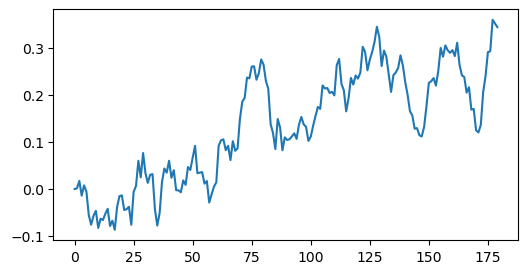

28,28,31,26,29,27,19,16,19,21,15,18,18,20,21,16,18,14,22,26,26,21,21,22,16,27,29,37,32,40,33,30,33,33,21,16,20,30,35,34,37,32,34,28,28,27,31,29,35,34,39,42,33,34,34,30,31,24,26,29,30,43,44,45,41,42,38,44,41,42,51,57,58,65,65,69,69,65,67,71,70,64,62,50,47,41,51,49,41,45,44,45,46,47,45,50,52,50,49,44,46,49,52,55,55,63,62,62,60,60,59,69,71,63,61,54,58,65,63,66,65,67,75,74,68,71,74,77,82,79,69,74,72,66,60,66,67,68,73,69,64,60,54,53,48,48,46,46,49,56,63,64,65,63,68,75,72,76,74,73,74,72,77,69,66,65,60,62,55,55,48,47,49,60,66,74,74,84,83,82,
random_seed:  5


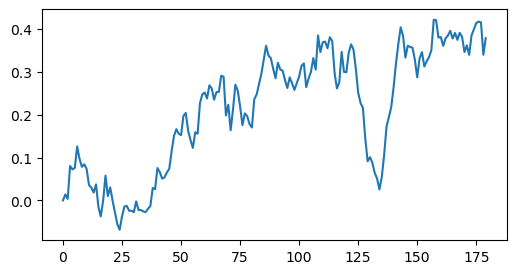

24,26,25,36,35,35,42,38,35,36,35,29,29,27,30,22,19,24,33,26,29,24,20,16,14,19,22,22,21,21,20,24,21,21,21,20,22,22,28,28,35,34,32,32,34,35,41,46,48,47,46,52,53,48,44,42,47,47,57,60,60,58,63,62,58,60,60,66,66,53,56,48,55,63,61,56,49,53,52,50,49,58,60,63,66,71,76,73,72,68,65,70,68,68,64,62,65,63,61,63,66,69,70,62,65,67,72,68,79,74,77,77,75,79,77,67,62,64,74,67,67,74,76,75,68,60,57,55,45,37,39,37,33,32,28,32,40,49,52,55,62,70,77,82,79,72,76,75,75,71,65,72,74,69,71,72,74,84,84,79,79,76,78,79,81,78,80,78,80,79,74,76,73,79,81,83,84,84,73,78,
random_seed:  6


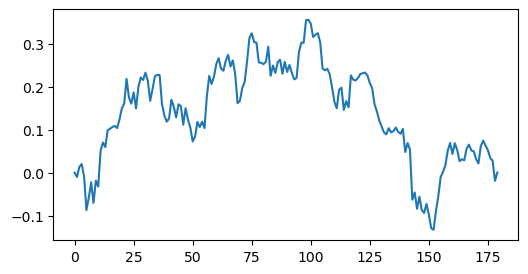

34,32,35,36,32,21,25,30,23,31,29,41,44,42,48,48,49,49,48,51,55,57,65,59,57,60,55,62,65,64,67,64,57,61,66,66,66,56,53,51,52,58,56,52,56,56,50,55,51,49,44,46,50,49,51,48,59,66,63,65,70,72,68,68,71,73,69,71,66,57,57,62,64,70,78,80,77,77,70,70,70,71,75,66,69,67,70,71,66,70,67,69,67,65,65,74,77,77,84,84,83,79,80,80,77,68,68,68,66,62,57,55,61,62,54,57,55,66,65,64,65,66,67,67,66,63,62,56,54,51,49,47,46,48,47,47,49,47,47,48,40,43,41,25,27,21,26,21,20,23,20,15,14,21,26,32,34,36,41,43,40,43,41,37,38,38,42,43,41,41,38,37,42,44,43,41,38,38,31,34,
random_seed:  7


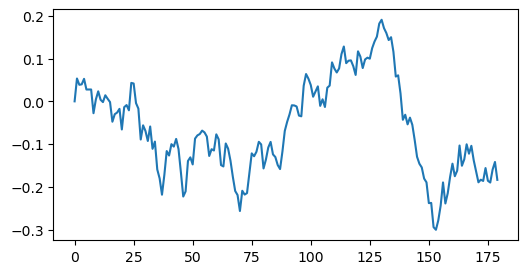

57,65,63,63,65,61,61,61,53,58,61,58,57,59,58,57,51,53,54,55,48,55,56,54,63,63,57,55,45,49,47,44,49,41,44,35,32,26,33,41,39,43,42,45,41,34,26,27,37,39,36,45,46,46,48,47,46,39,41,41,46,45,36,36,43,42,38,32,27,26,21,28,26,27,33,40,39,41,44,43,35,38,42,44,40,39,36,35,41,47,50,53,56,56,56,53,52,62,66,65,63,59,61,62,56,58,55,62,63,70,68,67,68,73,76,70,71,71,69,66,74,72,68,71,72,72,75,77,79,83,84,82,80,78,79,74,66,66,60,51,53,50,52,49,44,39,37,35,32,30,23,23,15,14,18,23,30,23,27,32,37,32,34,43,36,38,43,40,42,38,34,30,31,31,35,31,30,35,37,31,
random_seed:  8


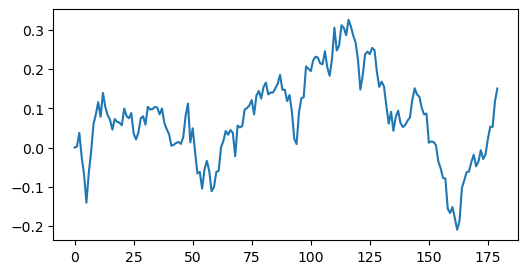

42,42,47,39,33,24,33,41,50,53,57,52,60,55,53,51,48,51,50,50,49,55,52,52,53,47,45,47,52,52,50,56,55,55,55,55,53,55,50,48,46,43,43,43,44,43,45,52,57,44,48,41,33,34,28,35,37,34,27,29,34,34,42,44,47,46,48,47,39,49,49,49,55,55,56,58,53,59,61,58,62,64,60,60,60,62,63,66,61,61,57,59,54,45,43,54,58,59,69,68,67,71,72,72,70,70,74,69,66,71,82,74,76,83,82,79,84,82,79,77,71,61,66,73,74,73,75,74,67,62,64,62,56,50,54,48,52,54,50,49,49,51,52,58,62,60,59,55,53,53,44,44,44,43,37,35,32,32,21,20,22,18,14,18,28,31,34,34,37,40,36,37,41,38,40,45,49,49,57,62,


In [3]:
####################################
### Generate continuous time series
####################################

### Brownian Motion

traj_name = 'brownian_motion'
Nt = 180 # number of steps
a = 0 # drift

# other hyper-parameters
dt =  0.1 # time step
tspan = np.linspace(0, Nt*dt, Nt)
sigma = 0.1
num_series = 5
for traj_idx in range(num_series):
    random_seed = 4+traj_idx
    print("random_seed: ", random_seed)
    np.random.seed(random_seed)
    # Initialize the time series
    x = 0  # Starting point
    time_series = [x]
    mean_series = [x]
    sigma_series = [0]

    # Generate the drift-diffusion time series
    for t in range(1, Nt):
        x_mean = x + a*dt
        x_sigma = sigma * np.sqrt(dt)
        dW =  np.random.normal()  # Wiener process (Brownian motion)
        x = x_mean + x_sigma * dW
        
        time_series.append(x)
        mean_series.append(x_mean)
        sigma_series.append(x_sigma)
        
    plt.figure(figsize=(6, 3))
    plt.plot(time_series, alpha = 1)
    plt.show()

    rescaled_full_series, full_series, rescaled_true_mean_arr, rescaled_true_sigma_arr = serialize_gaussian(prec, time_series, mean_series, sigma_series)

    print(full_series)



good seed: 0


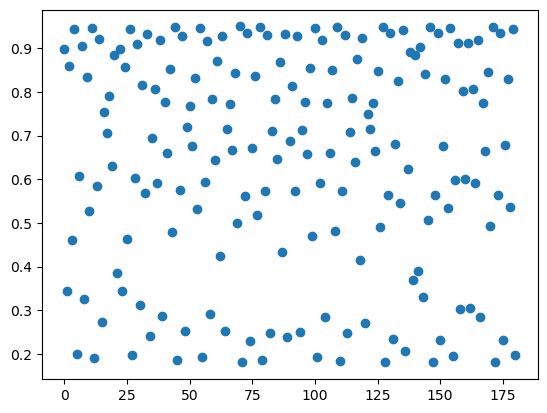

80,29,76,40,84,16,53,80,28,74,46,84,15,51,82,23,67,62,70,55,79,33,80,29,76,40,84,16,53,81,27,72,50,83,20,61,71,52,82,24,69,58,76,42,84,15,50,83,21,63,68,60,74,46,84,16,52,81,25,69,57,77,37,83,21,63,68,59,75,44,84,14,49,83,19,59,74,45,84,15,50,83,21,63,69,57,77,37,83,20,61,72,50,83,21,63,69,58,76,41,84,16,52,82,24,69,58,76,42,84,15,50,83,21,62,70,56,78,36,82,23,66,63,69,59,75,43,84,15,49,83,19,60,73,48,84,17,55,79,32,79,34,80,28,75,44,84,15,49,83,19,60,74,47,84,16,53,81,26,71,53,81,26,72,52,82,24,68,59,75,43,84,15,49,83,19,60,74,47,84,16,
good seed: 1


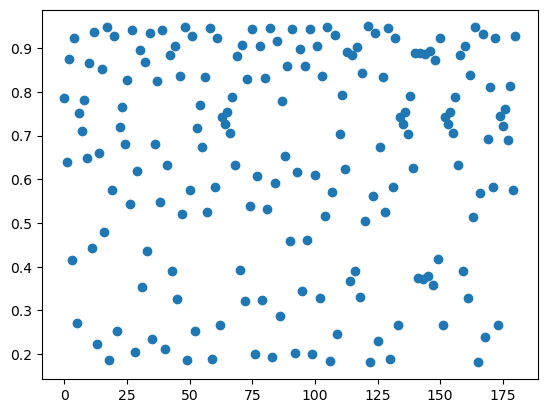

70,56,78,36,82,23,66,63,69,57,77,38,83,18,58,76,42,84,15,50,83,21,64,68,60,73,48,84,17,54,80,30,77,38,83,19,60,73,48,84,17,56,78,34,80,28,74,45,84,15,50,83,21,63,68,59,74,46,84,15,51,82,22,66,64,67,62,70,56,78,34,81,27,73,47,84,16,53,81,28,74,46,84,16,52,82,24,69,58,76,40,84,17,54,80,29,76,40,84,16,54,80,28,74,45,84,15,50,83,20,62,70,55,79,32,79,33,80,28,75,44,84,14,49,83,19,59,74,46,84,15,51,82,22,66,64,67,62,70,55,79,32,79,32,79,33,79,31,78,36,82,22,66,64,67,62,70,56,78,34,80,28,74,45,84,15,50,83,20,61,72,51,82,22,66,64,67,61,72,50,83,
good seed: 2


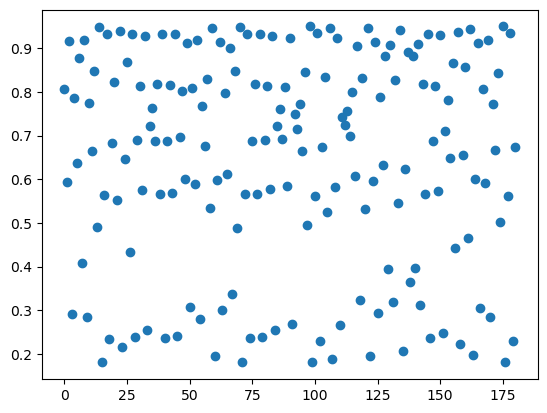

71,52,81,25,70,56,78,35,82,24,69,58,75,43,84,15,49,83,19,60,73,48,84,18,57,77,37,83,20,61,72,51,82,21,64,68,61,72,50,83,20,61,72,50,83,20,61,71,53,81,26,72,52,82,24,68,60,74,47,84,16,52,81,25,71,54,80,29,75,42,84,15,50,83,20,61,72,50,83,20,61,72,51,82,21,64,67,61,72,51,82,23,66,63,68,59,75,43,84,15,49,83,19,59,74,46,84,15,51,82,22,66,64,67,62,71,53,81,27,74,47,84,16,52,81,25,70,56,78,34,81,27,73,48,84,17,55,79,31,78,34,81,27,72,50,83,20,61,72,50,83,21,63,69,57,77,38,83,18,58,76,40,84,16,53,81,26,72,52,82,24,68,59,75,44,84,14,49,83,19,59,
good seed: 3


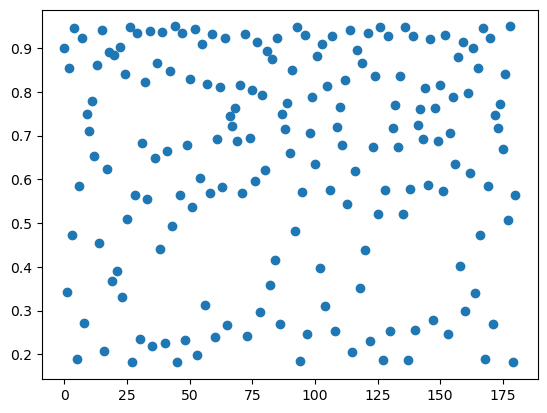

80,29,76,41,84,15,51,82,23,66,63,69,57,76,39,84,17,55,79,32,79,34,80,28,75,44,84,15,49,83,19,60,73,48,83,18,57,77,38,83,19,59,75,43,84,15,49,83,19,60,74,47,84,16,53,81,27,72,50,83,20,61,72,51,82,22,66,64,67,61,72,50,83,20,61,71,52,81,25,70,55,79,31,78,36,82,23,66,63,69,58,75,42,84,15,50,83,20,62,70,56,78,34,81,26,72,50,83,21,64,68,60,73,47,84,17,54,80,30,77,38,83,19,59,74,45,84,15,50,83,21,63,68,59,74,46,84,15,51,82,21,64,67,61,72,52,82,23,67,61,72,50,83,21,62,70,56,78,35,81,25,71,54,80,29,76,41,84,15,51,82,23,66,63,68,59,75,44,84,14,49,
good seed: 4


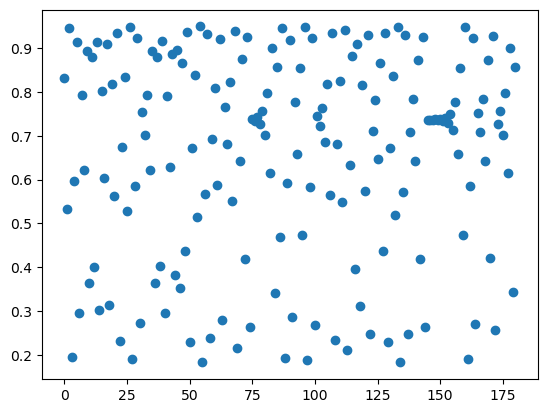

74,47,84,16,52,81,25,70,55,79,31,78,34,81,25,71,53,81,27,73,49,83,19,59,74,46,84,15,51,82,23,67,62,70,55,79,31,78,35,81,25,70,55,79,33,80,30,77,38,83,19,59,74,45,84,14,50,83,20,61,72,52,82,23,68,60,73,48,84,17,56,78,36,82,22,65,65,66,64,67,62,71,54,80,29,76,41,84,15,52,82,24,69,58,76,41,84,15,51,82,22,66,64,68,60,73,49,83,19,60,73,48,84,17,56,78,34,81,26,72,50,83,21,63,69,57,77,38,83,19,59,74,45,84,15,50,83,20,63,69,56,78,36,82,22,65,65,65,65,65,65,65,65,64,66,63,69,58,76,41,84,15,51,82,23,66,63,69,56,78,36,82,21,64,67,62,71,54,80,29,76,


In [14]:
### Logistic Map
traj_name = 'logistic_map'


Nt = 181

sigma = 0
r = 3.9
r = 3.8

### Logistic Map
def logistic_map(r, x):
    return r * x * (1 - x)

### Manual differentiation
def logistic_map_diff(r, x):
    return np.abs(r * (1-2*x))

num_series = 5

counter = -1
traj_idx = 0
while counter < num_series-1:
    random_seed = traj_idx
    np.random.seed(random_seed)
    traj_idx += 1
    x = np.random.uniform() * 0.7
    x_diff = 0 # Initial uncertainty is zero
    time_series = []
    mean_series = []
    sigma_series = []
        
    for i in range(Nt):
        x_mean = logistic_map(r, x)
        x_sigma = x_diff * sigma
        x = logistic_map(r, x + sigma * np.random.normal())
        x_diff = logistic_map_diff(r, x)
        
        time_series.append(x)
        mean_series.append(x_mean)
        sigma_series.append(x_sigma)
    
    if np.any(np.abs(np.array(time_series))>1):
        # discard stray trajectories
        continue
    else:
        print(f"good seed: {traj_idx-1}")
        counter += 1
        
    plt.plot(time_series, alpha = 1, lw = 0, marker = 'o')
    plt.show()
    rescaled_full_series, full_series, rescaled_true_mean_arr, rescaled_true_sigma_arr = serialize_gaussian(prec, time_series, mean_series, sigma_series)

    print(full_series)

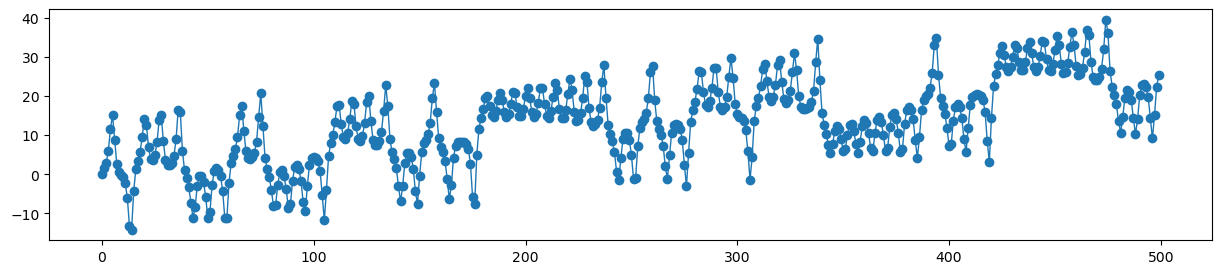

33,35,37,41,48,53,44,36,34,33,32,30,25,16,14,27,35,38,40,45,51,50,42,38,38,39,44,51,53,44,38,36,36,37,39,45,55,54,41,34,32,29,24,18,22,29,32,33,30,25,19,21,29,34,35,35,32,27,19,18,30,37,39,41,45,53,56,48,41,38,38,39,40,44,52,60,49,39,35,32,28,22,23,29,34,34,33,28,22,23,31,35,36,35,31,24,21,29,36,38,39,39,37,34,26,18,28,39,43,46,50,56,56,50,45,45,47,51,57,56,49,45,44,46,50,57,59,51,44,43,43,44,47,54,63,56,45,40,38,35,29,24,29,37,40,40,39,35,27,23,33,40,43,45,46,50,58,64,54,45,42,40,37,31,25,29,39,43,44,44,44,44,43,41,37,25,23,40,48,52,55,58,59,56,53,52,54,58,60,58,54,52,53,56,60,60,56,52,52,55,59,62,58,54,52,53,57,62,62,56,52,52,54,59,64,61,55,52,52,54,60,65,61,54,51,51,53,59,66,64,55,50,49,50,51,55,64,69,59,50,46,44,40,34,31,38,45,47,47,45,40,31,32,42,48,50,51,54,58,67,69,58,51,48,46,42,36,32,39,47,49,50,50,48,45,36,29,40,51,54,57,62,67,67,61,56,55,57,62,68,68,60,56,55,56,59,66,72,65,57,53,52,52,51,48,41,31,39,51,56,59,62,68,70,64,59,58,59,63,69,71,64,58,57,58,61,67,73,68,59,56,55,55,5

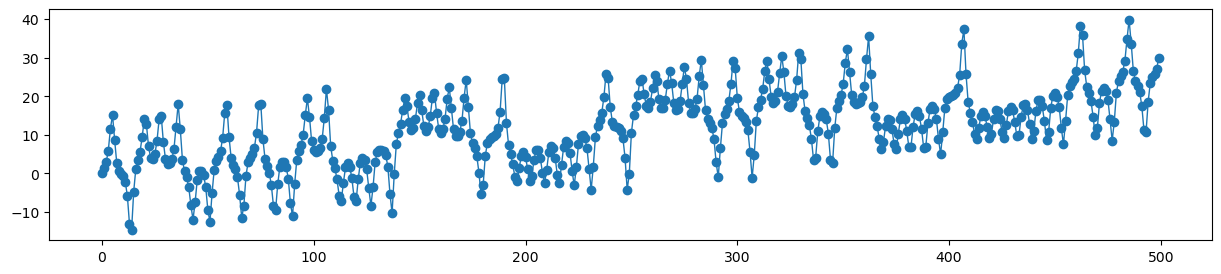

33,35,37,41,48,53,44,37,34,33,32,31,26,17,14,27,35,38,41,45,51,50,42,38,38,40,44,51,52,44,38,37,37,38,41,49,56,48,38,34,32,29,23,18,24,31,34,34,33,29,21,17,27,35,37,39,41,45,54,56,46,38,36,35,32,26,19,22,32,37,39,40,42,47,56,57,45,38,36,34,29,22,21,30,36,37,37,35,31,23,19,30,38,41,43,46,53,58,52,44,41,40,41,42,45,52,61,55,42,38,35,31,26,24,30,35,37,36,32,26,24,31,37,38,38,35,28,23,29,37,40,41,41,41,39,36,27,20,33,43,47,50,54,58,56,50,48,48,51,57,59,54,49,47,49,52,58,60,54,48,47,48,52,58,62,55,48,46,46,47,51,59,65,56,47,43,42,39,34,26,30,39,44,45,45,46,46,49,54,65,65,50,43,40,36,32,31,35,39,40,39,35,31,32,38,41,41,38,33,30,35,40,43,42,39,33,30,36,42,44,43,40,34,29,35,43,46,46,45,42,35,28,36,45,49,51,53,59,66,65,56,50,49,49,48,47,45,39,28,33,47,53,56,59,64,65,60,56,55,57,62,66,64,58,55,55,58,63,68,63,57,54,55,57,63,69,65,57,54,53,55,58,66,71,63,54,51,50,48,45,37,32,42,50,53,55,57,63,71,68,59,54,52,52,51,48,41,32,39,51,55,58,62,68,71,65,59,57,58,61,67,72,67,59,56,55,56,59,64,74,71,60,54,5

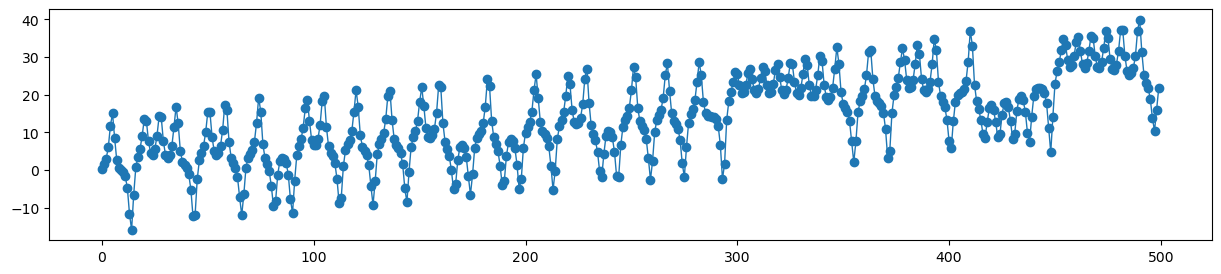

35,36,38,42,49,53,45,38,35,34,34,32,28,20,14,26,35,39,41,46,51,51,44,40,40,41,46,52,52,44,39,38,39,42,49,55,50,41,37,36,35,33,28,19,20,31,38,40,43,47,54,54,45,41,39,40,42,48,56,54,44,39,37,35,32,25,19,26,35,39,40,41,44,50,59,54,43,38,36,34,29,22,24,33,37,39,38,37,33,25,20,31,39,42,45,48,55,58,51,44,43,43,45,49,58,59,49,42,40,39,37,31,23,25,36,41,43,44,47,54,61,55,46,42,41,39,36,29,23,31,40,43,45,47,51,59,61,51,45,43,42,40,36,28,24,34,42,45,47,51,57,62,56,48,46,45,46,48,53,63,62,50,44,42,39,34,28,30,38,42,43,42,39,32,26,33,42,45,46,48,50,56,65,62,51,45,43,41,36,29,31,39,44,45,44,42,36,28,31,42,47,49,50,54,61,66,59,50,47,46,45,42,36,28,34,45,49,51,54,59,66,63,54,50,50,50,52,56,65,68,57,49,47,44,40,34,32,40,46,48,47,45,41,32,32,43,49,51,52,55,61,69,65,55,51,49,48,45,38,31,37,47,51,53,55,59,66,70,61,53,51,50,48,44,37,32,42,50,53,55,58,64,70,66,57,53,53,52,52,52,51,49,43,31,37,51,57,60,64,67,67,63,60,60,63,67,68,65,61,60,61,65,69,67,63,60,60,63,68,70,66,61,60,61,65,70,70,64,60,60,62,66,72,6

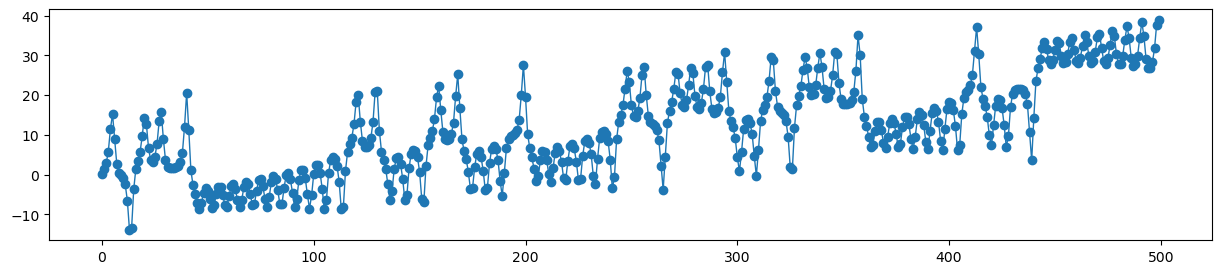

33,35,37,41,48,53,45,36,34,33,32,30,24,14,15,28,35,37,40,46,52,50,42,38,37,39,43,51,54,45,38,36,35,35,35,35,36,37,40,49,60,48,34,29,27,23,22,24,27,28,27,25,22,23,26,29,29,26,23,22,26,29,30,28,24,22,24,29,31,30,27,23,23,28,31,31,29,25,22,26,30,32,31,28,23,23,29,33,33,31,27,22,25,31,34,34,32,26,22,26,33,36,36,34,28,21,24,33,38,39,38,36,31,21,22,34,41,43,45,50,57,59,51,44,42,42,43,45,51,61,61,48,41,38,35,30,24,27,35,38,39,37,32,25,26,35,40,41,41,39,34,25,24,36,43,45,47,51,59,62,54,47,45,44,45,46,50,59,66,55,45,41,38,34,28,29,35,40,41,39,34,28,29,37,41,42,41,38,31,26,34,42,45,46,46,47,48,51,59,69,59,46,42,39,35,31,32,38,41,41,38,33,30,35,40,42,41,37,32,31,38,42,43,42,37,31,31,39,44,45,44,40,33,30,38,45,47,47,47,44,38,28,32,45,50,53,56,62,67,64,56,52,52,54,58,66,69,59,52,50,50,49,48,44,36,28,39,50,54,57,62,67,67,60,56,56,58,63,69,67,59,55,55,57,61,69,70,61,55,53,54,55,59,67,74,64,54,51,49,45,39,34,40,48,51,51,50,47,39,33,41,51,54,56,59,64,72,71,61,56,54,53,53,51,45,35,35,49,56,59,62,68,72,6

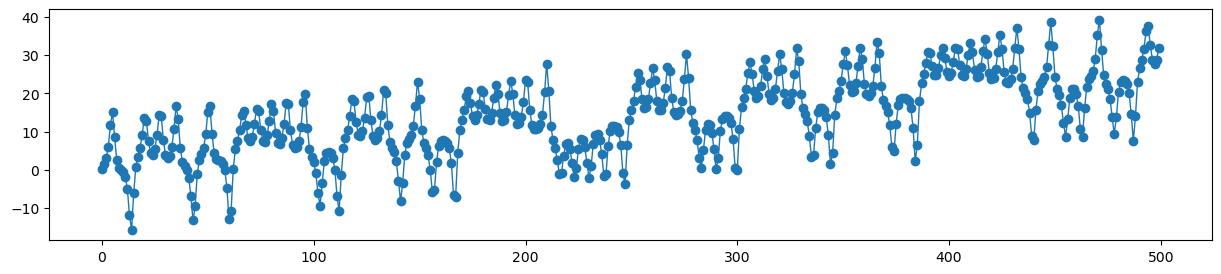

35,36,38,42,49,54,45,38,35,34,34,32,28,19,14,27,36,39,42,46,52,51,44,40,40,41,46,53,52,44,39,38,39,42,48,56,52,42,37,36,35,32,26,18,22,33,38,40,42,46,54,56,46,40,38,38,37,37,34,29,18,21,35,41,44,48,53,54,49,45,44,46,50,55,54,48,44,44,46,51,56,54,47,43,43,45,50,57,56,48,43,42,42,44,49,57,60,49,41,39,37,33,27,23,30,37,40,40,40,38,34,26,21,33,42,45,48,52,58,57,50,46,46,47,52,59,59,51,46,44,45,47,53,61,60,49,44,42,40,37,31,24,30,40,43,45,46,49,56,64,58,48,43,42,39,35,27,28,37,43,44,44,44,44,42,37,26,25,40,48,51,54,59,61,57,52,51,53,57,61,60,55,51,51,54,58,63,60,53,51,51,54,59,64,60,53,50,50,52,57,64,64,55,49,48,48,48,50,53,60,70,61,49,44,42,38,33,33,39,43,43,41,37,32,35,42,45,45,42,37,32,36,43,46,46,44,40,32,33,42,48,49,49,49,47,43,33,30,43,51,54,57,62,67,64,58,55,55,58,63,68,64,57,54,55,57,62,69,67,59,54,53,53,54,57,65,73,65,54,50,48,44,39,35,41,48,50,49,47,41,35,38,47,52,53,53,52,50,45,35,34,48,55,58,62,67,70,66,61,58,59,62,68,72,66,60,58,58,61,67,73,68,60,57,57,58,60,66,75,71,60,55,53,5

In [15]:
traj_name = 'lorenz_system_with_drift'
# hyper-parameter to load from json

Nt = 500


tspan = np.linspace(0, 19, Nt)
tspan = np.linspace(0, 13.5, Nt)
tspan = np.linspace(0, 50, Nt)

sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0
# drift_rate = 0.4
drift_rate = 0.05

def lorenz(state, t):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

counter = -1
traj_idx = 0
num_series = 5
for i in range(num_series):
    # Specific initial condition
    
    random_seed = i+2
    np.random.seed(random_seed)
    initial_state = [np.random.uniform()*0.3, 2.01, 23.02] 
    
    solution = odeint(lorenz, initial_state, tspan)
    X = solution[:, 0]
    # Add drift to X
    drift = drift_rate * np.arange(len(X))
    X = X + drift
    time_series = X.tolist()
    mean_series = time_series
    sigma_series = [0] * Nt
    
    plt.figure(figsize=(15, 3))        
    plt.plot(time_series, alpha = 1, lw = 1, marker = 'o')
    plt.show()
    rescaled_full_series, full_series, rescaled_true_mean_arr, rescaled_true_sigma_arr = serialize_gaussian(prec, time_series, mean_series, sigma_series)
    
    print(full_series)    